Using device: cuda

=== Loading CIFAR-10 ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training samples: 50000
Test samples: 10000

=== Model Architecture ===
MLP(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)
Total parameters: 3676682

=== Training for 50 epochs ===


Epoch 1/50:   0%|          | 0/391 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [5/50] | Train Loss: 1.4703 | Train Acc: 47.48% | Test Acc: 45.99%


...

Epoch [30/50] | Train Loss: 0.9124 | Train Acc: 67.61% | Test Acc: 52.08%


Epoch [35/50] | Train Loss: 0.8353 | Train Acc: 70.00% | Test Acc: 52.26%


Epoch [40/50] | Train Loss: 0.7591 | Train Acc: 72.87% | Test Acc: 51.04%


Epoch [45/50] | Train Loss: 0.7033 | Train Acc: 74.88% | Test Acc: 51.16%


Epoch [50/50] | Train Loss: 0.6510 | Train Acc: 76.45% | Test Acc: 51.80%

=== FINAL RESULTS ===
Final Training Accuracy: 76.45%
Final Test Accuracy: 51.80%
Best Test Accuracy: 53.11%


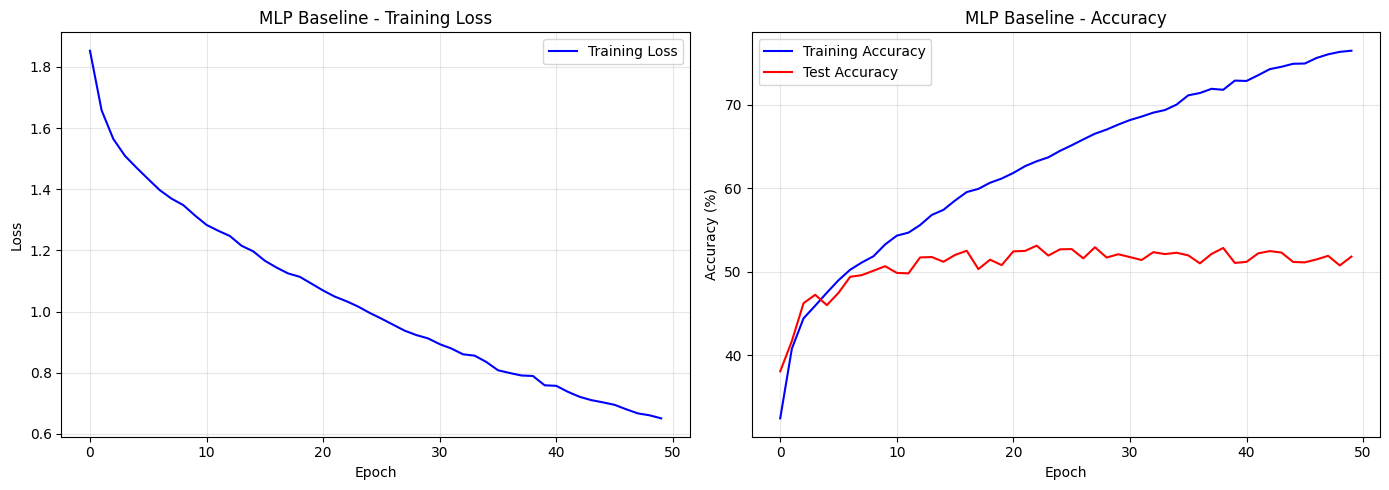


✓ Results saved to 'mlp_baseline_results.png'

=== KEY INSIGHT ===
MLP Baseline achieves ~51.8% accuracy on CIFAR-10.
This is your baseline! CNNs will exploit spatial structure to do MUCH better.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================
# 1. LOAD CIFAR-10 AND FLATTEN IMAGES
# ============================================
print("\n=== Loading CIFAR-10 ===")
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# ============================================
# 2. DEFINE 3-LAYER MLP
# ============================================
class MLP(nn.Module):
    def __init__(self, input_size=3072, hidden1=1024, hidden2=512, num_classes=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model = MLP().to(device)
print(f"\n=== Model Architecture ===")
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

# ============================================
# 3. TRAINING SETUP
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accs = []
test_accs = []

# ============================================
# 4. TRAINING LOOP
# ============================================
num_epochs = 50

print(f"\n=== Training for {num_epochs} epochs ===")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_accs.append(test_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

# ============================================
# 5. FINAL RESULTS
# ============================================
print(f"\n=== FINAL RESULTS ===")
print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")
print(f"Best Test Accuracy: {max(test_accs):.2f}%")

# ============================================
# 6. VISUALIZATION
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Training Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MLP Baseline - Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_accs, label='Training Accuracy', color='blue')
ax2.plot(test_accs, label='Test Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MLP Baseline - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Results saved to 'mlp_baseline_results.png'")
print("\n=== KEY INSIGHT ===")
print(f"MLP Baseline achieves ~{test_accs[-1]:.1f}% accuracy on CIFAR-10.")
print("This is your baseline! CNNs will exploit spatial structure to do MUCH better.")